In [9]:
import pandas as pd
import glob
import os
import requests
import rasterio
import numpy as np
import json
import unicodedata
import matplotlib.pyplot as plt

Combinam cele 3 dataseturi pentru copaci, clima si sol si salvam in "dataset_full.csv".

Ne asiguram ca numele coloanelor nu contin spatii si ca anul nu contine caractere. Dam merge pe judet.

In [ ]:

# 1. Funcție pentru eliminarea diacriticelor și curățarea textului
def normalizeaza_nume(text):
    if not isinstance(text, str): return text
    # Elimina spatii albe de la inceput/sfarsit
    text = text.strip()
    # Normalizeaza caracterele (ex: ș -> s, ț -> t)
    text = ''.join(c for c in unicodedata.normalize('NFKD', text)
                  if unicodedata.category(c) != 'Mn')
    return text

# 2. Încarcă datele
df_copaci = pd.read_csv('date_meri.csv')
df_sol = pd.read_csv('sol_judete_romania.csv')
df_clima = pd.read_csv('clima_nasa_judete_romania.csv')

# 3. Aplică normalizarea pe toate cele 3 tabele
df_copaci['Judet'] = df_copaci['Judet'].apply(normalizeaza_nume)
df_sol['Judet'] = df_sol['Judet'].apply(normalizeaza_nume)
df_clima['Judet'] = df_clima['Judet'].apply(normalizeaza_nume)

# 4. Asigură-te că coloana 'An' este de același tip (Integer)
df_copaci['An'] = df_copaci['An'].astype(int)
df_clima['An'] = df_clima['An'].astype(int)

# 5. Realizează Merge-ul pas cu pas
# Prima data Copaci + Sol (pe Judet)
df_merge_1 = pd.merge(df_copaci, df_sol, on='Judet', how='inner')
print(f"Dupa primul merge (Sol): {len(df_merge_1)} randuri")

# Apoi rezultatul + Clima (pe Judet si An)
df_final = pd.merge(df_merge_1, df_clima, on=['Judet', 'An'], how='inner')
print(f"Dupa al doilea merge (Clima): {len(df_final)} randuri")

# 6. Salvare
if len(df_final) > 0:
    df_final.to_csv("dataset_full.csv", index=False)
    print("Succes! Fișierul dataset_full.csv conține acum datele unite.")
else:
    print("EROARE: Tot nu avem potriviri. Verifică dacă anii din Clima se suprapun cu anii din Copaci.")

Dupa primul merge (Sol): 1025 randuri
Dupa al doilea merge (Clima): 1025 randuri
Succes! Fișierul dataset_full.csv conține acum datele unite.


Curatam datasetul de toate coloanele de care nu avem nevoie si salvam in date_predicite_meri. 

In [ ]:

import importlib
import config

# Reîncărcăm fișierul de configurare pentru a prelua ultimele modificări
importlib.reload(config)
from config import PARAMETRI_COPACI, PARAMETRI_SOL, PARAMETRI_CLIMA

# 1. Extragem cheile din dicționare (păstrează ordinea din config.py)
cols_copaci = list(PARAMETRI_COPACI.keys())
cols_sol = list(PARAMETRI_SOL.keys())

# 2. Aplatizăm dicționarul de climă
cols_clima = []
for anotimp_dict in PARAMETRI_CLIMA.values():
    cols_clima.extend(list(anotimp_dict.keys()))

# 3. CONSTRUIREA LISTEI FINALE ÎN ORDINEA DORITĂ
# Punem explicit 'Judet' și 'An' la început
toate_coloanele_ordonate = ['Judet', 'An'] + cols_copaci + cols_sol + cols_clima

# 4. Curățăm lista de eventuale duplicate păstrând ordinea
# (Ex: dacă 'An' apare și în lista de climă, îl lăsăm doar la început)
coloane_finale = []
for col in toate_coloanele_ordonate:
    if col not in coloane_finale:
        coloane_finale.append(col)

# 5. Aplicăm filtrarea pe df_final
if 'df_final' in locals() or 'df_final' in globals():
    # Păstrăm doar coloanele care chiar există în tabel
    coloane_de_extras = [c for c in coloane_finale if c in df_final.columns]
    
    df_redus = df_final[coloane_de_extras]

    # Salvare în CSV
    df_redus.to_csv('date_predictie_meri.csv', index=False)
    
    print("✅ Fișier salvat cu ordinea coloanelor:")
    print(f"1. Identificare: Judet, An")
    print(f"2. Copaci: {cols_copaci}")
    print(f"3. Sol: {cols_sol}")
    print(f"4. Clima: {len(cols_clima)} coloane")
else:
    print("❌ Eroare: df_final nu a fost găsit în memorie.")

✅ Fișier salvat cu ordinea coloanelor:
1. Identificare: Judet, An
2. Copaci: ['Numar_Pomi', 'Kg_pe_Pom', 'Tone_Totale', 'Rootstock_ID']
3. Sol: ['phh2o', 'clay', 'sand', 'silt', 'soc', 'nitrogen', 'cec']
4. Clima: 18 coloane


In [7]:
df= pd.read_csv('date_predictie_meri.csv')


# 1. Verificare initiala
print("Shape initial:", df.shape)
print("Nule per coloana:\n", df.isnull().sum())
print("Duplicate:", df.duplicated().sum())

# Verifica
print(df[df['Tone_Totale'].isnull()][['Judet', 'An', 'Numar_Pomi', 'Kg_pe_Pom', 'Tone_Totale']].head())

# Recalculeaza Tone_Totale unde lipseste
# Tone_Totale = (Kg_pe_Pom * Numar_Pomi) / 1000
mask = df['Tone_Totale'].isnull()
df.loc[mask, 'Tone_Totale'] = (df.loc[mask, 'Kg_pe_Pom'] * df.loc[mask, 'Numar_Pomi']) / 1000

print("Nule dupa recalculare:", df['Tone_Totale'].isnull().sum())

print(df['zile_inghet_vara'].value_counts())
print("\nNon-zero:", (df['zile_inghet_vara'] != 0).sum())
print("Total randuri:", len(df))

# 4. Elimina coloanele care "trisaza" modelul
df = df.drop(columns=['Tone_Totale', 'Numar_Pomi', "zile_inghet_vara"])


# 6. Verifica tipuri de date
print("\nTipuri de date:\n", df.dtypes)

# 7. Salveaza
df.to_csv('date_curate.csv', index=False)
print("\nSalvat! Shape final:", df.shape)         # util sa vezi daca o coloana numerica e citita ca string

Shape initial: (1025, 26)
Nule per coloana:
 Judet                   0
An                      0
Numar_Pomi              0
Kg_pe_Pom               0
Tone_Totale            25
Rootstock_ID            0
phh2o                   0
clay                    0
sand                    0
silt                    0
soc                     0
nitrogen                0
cec                     0
temp_medie_vara         0
precipitatii_vara       0
umid_sol_rad_vara       0
zile_inghet_vara        0
temp_medie_an           0
precipitatii_an         0
cdd10_an                0
precipitatii_toamna     0
temp_medie_toamna       0
umid_sol_rad_toamna     0
zile_inghet_toamna      0
temp_min_iarna          0
zile_inghet_iarna       0
dtype: int64
Duplicate: 0
     Judet    An  Numar_Pomi  Kg_pe_Pom  Tone_Totale
900  Timis  2000   1434226.0        7.0          NaN
901  Timis  2001    974580.0        8.0          NaN
902  Timis  2002    919285.0        3.0          NaN
903  Timis  2003    882163.0        8.0  

In [8]:
df = pd.read_csv('date_curate.csv')
print("Shape initial:", df.shape)
print("Nule per coloana:\n", df.isnull().sum())
print("Duplicate:", df.duplicated().sum())


Shape initial: (1025, 23)
Nule per coloana:
 Judet                  0
An                     0
Kg_pe_Pom              0
Rootstock_ID           0
phh2o                  0
clay                   0
sand                   0
silt                   0
soc                    0
nitrogen               0
cec                    0
temp_medie_vara        0
precipitatii_vara      0
umid_sol_rad_vara      0
temp_medie_an          0
precipitatii_an        0
cdd10_an               0
precipitatii_toamna    0
temp_medie_toamna      0
umid_sol_rad_toamna    0
zile_inghet_toamna     0
temp_min_iarna         0
zile_inghet_iarna      0
dtype: int64
Duplicate: 0


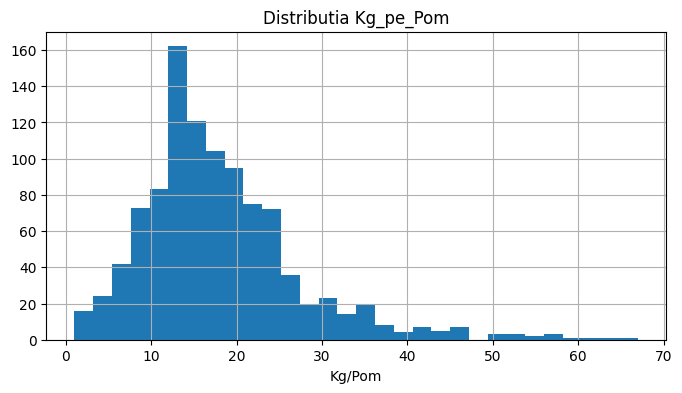

count    1025.000000
mean       17.920976
std         9.351042
min         1.000000
25%        12.000000
50%        16.000000
75%        22.000000
max        67.000000
Name: Kg_pe_Pom, dtype: float64


In [10]:
df['Kg_pe_Pom'].hist(bins=30, figsize=(8,4))
plt.title('Distributia Kg_pe_Pom')
plt.xlabel('Kg/Pom')
plt.show()

print(df['Kg_pe_Pom'].describe())

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))
df.boxplot(column='Kg_pe_Pom', by='Judet', ax=ax, rot=90)
plt.title('Outlieri per Judet')
plt.suptitle('')  # elimina titlul automat pandas
plt.xlabel('Judet')
plt.ylabel('Kg/Pom')
plt.tight_layout()
plt.show()

Numar outlieri: 40
          Judet    An  Kg_pe_Pom
68        Arges  2018       50.0
79        Bacau  2004       61.0
111       Bihor  2011       45.0
154    Botosani  2004       39.0
165    Botosani  2015       50.0
166    Botosani  2016       47.0
167    Botosani  2017       54.0
168    Botosani  2018       58.0
169    Botosani  2019       41.0
170    Botosani  2020       40.0
171    Botosani  2021       45.0
172    Botosani  2022       40.0
204      Brasov  2004       38.0
329   Constanta  2004       42.0
353     Covasna  2003       53.0
354     Covasna  2004       52.0
358     Covasna  2008       41.0
378   Dambovita  2003       43.0
379   Dambovita  2004       45.0
382   Dambovita  2007       57.0
385   Dambovita  2010       42.0
387   Dambovita  2012       44.0
388   Dambovita  2013       43.0
391   Dambovita  2016       47.0
393   Dambovita  2018       67.0
394   Dambovita  2019       38.0
395   Dambovita  2020       39.0
396   Dambovita  2021       45.0
397   Dambovita  2022   